In [ ]:
import numpy as np
from scipy.misc import face
from scipy.ndimage import zoom
from scipy.special import logsumexp
import torch

import deepgaze_pytorch
from deepgaze_pytorch import MSDBDataset

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

model = deepgaze_pytorch.DeepGazeMSDB(pretrained=True).to(DEVICE)

image = face()

# load precomputed centerbias log density (from MIT1003) over a 1024x1024 image
# you can download the centerbias from https://github.com/matthias-k/DeepGaze/releases/download/v1.0.0/centerbias_mit1003.npy
# alternatively, you can use a uniform centerbias via `centerbias_template = np.zeros((1024, 1024))`.
centerbias_template = np.load('../centerbias_mit1003.npy')
# rescale to match image size
centerbias = zoom(centerbias_template, (image.shape[0]/centerbias_template.shape[0], image.shape[1]/centerbias_template.shape[1]), order=0, mode='nearest')
# renormalize log density
centerbias -= logsumexp(centerbias)

def predict_log_density(image, centerbias):
    image_tensor = torch.tensor([image.transpose(2, 0, 1)]).to(DEVICE)
    centerbias_tensor = torch.tensor([centerbias]).to(DEVICE)

    # For a new/unknown dataset, use averaged parameters for generalization:
    log_density_prediction = model(image_tensor, centerbias_tensor, pixel_per_dva=35.0, dataset=None)
    return log_density_prediction

Using cache found in /u/b/chengn30/.cache/torch/hub/facebookresearch_dinov2_6a62615
/tmp/ipykernel_3711904/3645931666.py:14: DeprecationWarning: scipy.misc.face has been deprecated in SciPy v1.10.0; and will be completely removed in SciPy v1.12.0. Dataset methods have moved into the scipy.datasets module. Use scipy.datasets.face instead.
  image = face()


torch.Size([1, 768, 1024])
(768, 1024)


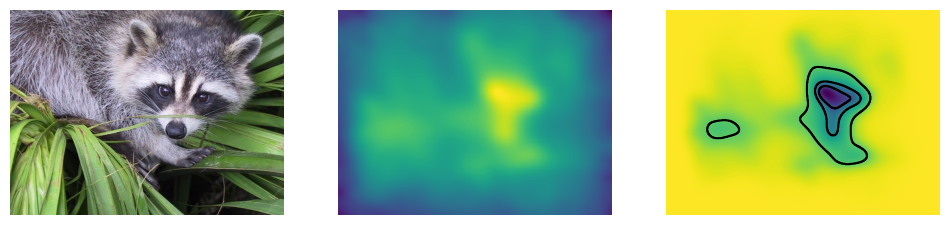

In [ ]:
import matplotlib.pyplot as plt
from pysaliency.plotting import visualize_distribution

INPUT_PATH = 'inputs'
OUTPUT_PATH = 'outputs'

def visualize_prediction(image, log_density_prediction):
    f, axs = plt.subplots(nrows=1, ncols=3, figsize=(12, 3))
    axs[0].imshow(image)
    axs[0].set_axis_off()
    axs[1].matshow(log_density_prediction.detach().cpu().numpy()[0])  # first image in batch
    axs[1].set_axis_off()
    visualize_distribution(log_density_prediction.detach().cpu().numpy()[0], ax=axs[2])
    axs[2].set_axis_off()
    plt.savefig(f'{OUTPUT_PATH}/my_plot.png')